# This Notebook Focuses on Getting SNIa residuals From the paper Itself # 

Here is the excerpt from the paper that tells us the values of alpha and beta:


We present our ZTF Hubble diagram for the 2629 non-peculiar SNe~Ia that pass our quality cuts in Figure~6. These SNe~Ia have been standardized using the methodology detailed in Ginolin et~al.~(2024), given the SALT2 stretch and color parameters and host local environmental properties (for example, Sullivan et~al.~2010; Rigault et~al.~2020). Following that paper, we adopt the nuisance parameter values $\alpha = -0.16$, $\beta = 3.05$, and $\gamma = 0.145~\mathrm{mag}$ (local-color step).


The standardized distance modulus for each Type~Ia supernova is computed using the Tripp (1998) relation:

The observed distance modulus in the SALT2 framework is given by: 

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0) + \alpha x_1 - \beta c + M_B,
$

NOTE: this convetnion assumes the quantities of alpha and beta both being greater than 0. This sign convention is worth adopting and keepting track of.

where $x_0$ is the overall flux normalization from the SALT2 light-curve fit, $x_1$ is the stretch parameter, and $c$ is the color parameter. The term $M_B$ represents the fiducial absolute magnitude of a standardized Type~Ia supernova, while $\alpha$ and $\beta$ are empirically determined coefficients describing the luminosity–stretch and luminosity–color relationships, respectively.

Using the Tripp 1998 paper, MB is assumed to be -19.5. The parameter $M_B$ represents the fiducial absolute magnitude of a standardized Type~Ia supernova in the rest-frame $B$~band. It corresponds to the intrinsic luminosity of an average SN~Ia with zero color and unit stretch after light-curve corrections. In the Tripp relation, $M_B$ anchors the absolute scale of supernova distances and is degenerate with the assumed value of the Hubble constant $H_0$.


Update from the supporting paper (Ginolin et. al. 2024):

$$
\begin{aligned}
\mu_{\mathrm{obs}} &= m_B - M_0 - \beta c + \alpha x_1 - \gamma p + \Delta_b \\
                   &= \mu - (\beta c - \alpha x_1 + \gamma p - \Delta_b)
\end{aligned}
$$

$\alpha = -0.16$, $\beta = 3.05$, and $\gamma = 0.145~\mathrm{mag}$ (local-color step).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

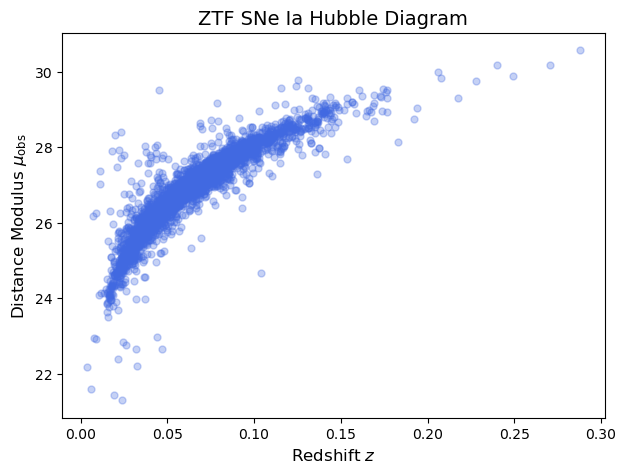

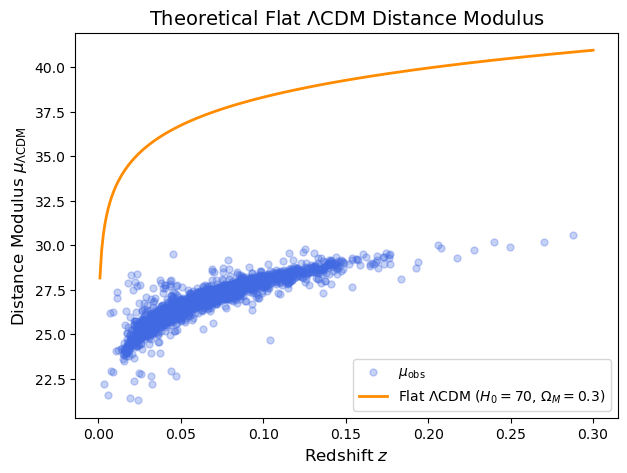

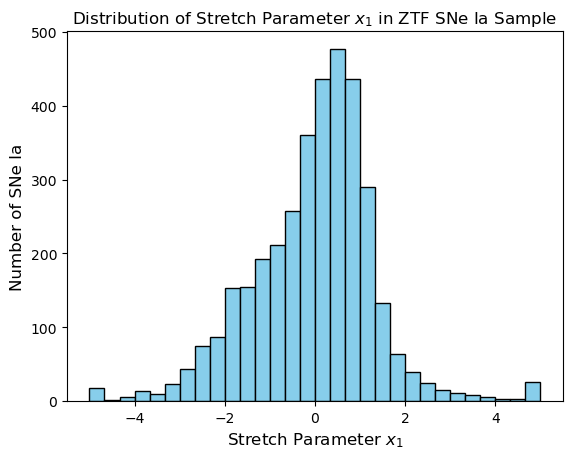

In [3]:
# Lets start by reading the data:

df = pd.read_csv("/Users/pittsburghgraduatestudent/repos/myc21_ztf_mu/ZTF_snia_data.csv")
df = df.dropna(subset=["x0", "x1", "c", "redshift"]).copy() # Drop anything with a missing light curve parameter.
df = df.reset_index(drop=True)

# Define parameters (using your specified signs and MB)
alpha = 0.16
beta = 3.05
MB = -19.5

# Compute the observed distance modulus
df["mu_obs"] = -2.5 * np.log10(df["x0"]) + alpha * df["x1"] - beta * df["c"] - MB

# Preview results
df[["ztfname", "x0", "x1", "c", "mu_obs"]].head()

plt.figure(figsize=(7,5))
plt.scatter(df["redshift"], df["mu_obs"], s=25, alpha=0.3, color="royalblue", label=r"$\mu_{\mathrm{obs}}$")
plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel(r"Distance Modulus $\mu_{\mathrm{obs}}$", fontsize=12)
plt.title("ZTF SNe Ia Hubble Diagram", fontsize=14)
plt.show()

# Define a fiducial flat ΛCDM cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)  # H0 in km/s/Mpc, Ω_M = 0.3

# Generate a smooth redshift grid
z_grid = np.linspace(0.001, 0.3, 300)  # avoid z=0 (log issues)

# Compute the theoretical distance modulus for each z
mu_grid = cosmo.distmod(z_grid).value  # distance modulus in magnitudes



# Plot the flat ΛCDM Hubble curve
plt.figure(figsize=(7,5))
plt.scatter(df["redshift"], df["mu_obs"], s=25, alpha=0.3, color="royalblue", label=r"$\mu_{\mathrm{obs}}$")
plt.plot(z_grid, mu_grid, color="darkorange", lw=2, label=r"Flat $\Lambda$CDM ($H_0=70$, $\Omega_M=0.3$)")
plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel(r"Distance Modulus $\mu_{\Lambda \mathrm{CDM}}$", fontsize=12)
plt.title("Theoretical Flat $\Lambda$CDM Distance Modulus", fontsize=14)
plt.legend()
plt.show()

plt.hist(df["x1"], bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Stretch Parameter $x_1$", fontsize=12)
plt.ylabel("Number of SNe Ia", fontsize=12)
plt.title("Distribution of Stretch Parameter $x_1$ in ZTF SNe Ia Sample")
plt.show()

        ztfname  redshift     mu_obs  mu_theory   residual
0  ZTF17aadlxmv  0.062019  26.755795  37.221017 -10.465222
1  ZTF18aaadqua  0.078672  29.180685  37.762769  -8.582084
2  ZTF18aaanzph  0.063718  26.473605  37.282294 -10.808689
3  ZTF18aaapivw  0.026341  24.175277  35.305293 -11.130016
4  ZTF18aaaqexr  0.070258  27.160126  37.504444 -10.344317


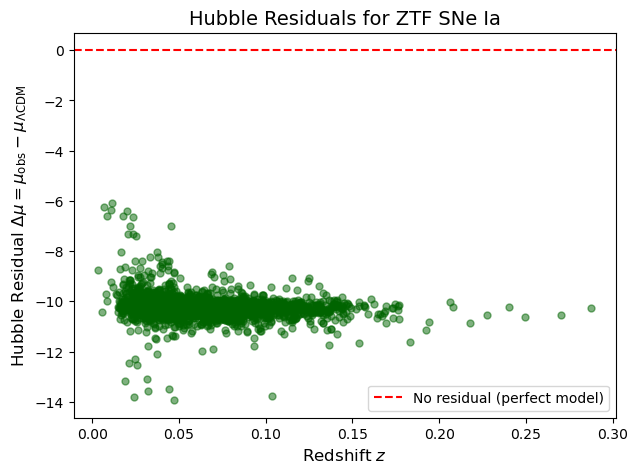

Mean residual: -10.235122631057266
RMS scatter: 0.41180435650665953


In [4]:
# Compute theoretical distance modulus for each SN using its redshift
df["mu_theory"] = cosmo.distmod(df["redshift"]).value

# Compute Hubble residuals (observed - theoretical)
df["residual"] = df["mu_obs"] - df["mu_theory"]

# Quick sanity check
print(df[["ztfname", "redshift", "mu_obs", "mu_theory", "residual"]].head())

# Plot residuals vs redshift
plt.figure(figsize=(7,5))
plt.scatter(df["redshift"], df["residual"], s=25, alpha=0.5, color="darkgreen")
plt.axhline(0, color="red", linestyle="--", label="No residual (perfect model)")
plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel(r"Hubble Residual $\Delta\mu = \mu_{\mathrm{obs}} - \mu_{\Lambda \mathrm{CDM}}$", fontsize=12)
plt.title("Hubble Residuals for ZTF SNe Ia", fontsize=14)
plt.legend()
plt.show()

# (Optional) summary statistics
print("Mean residual:", np.mean(df["residual"]))
print("RMS scatter:", np.std(df["residual"]))

New mean residual (after centering): 6.5272e-16


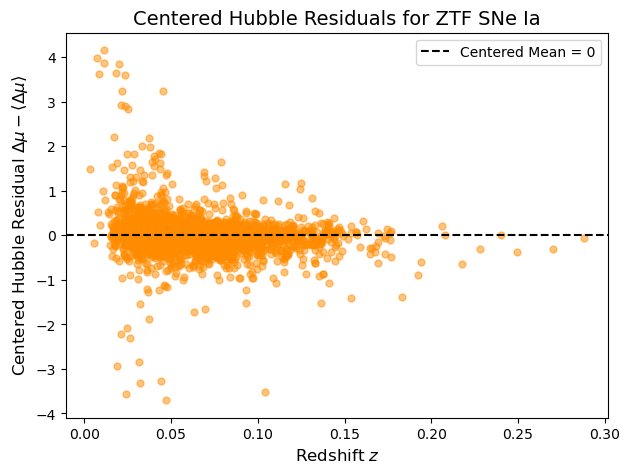

In [5]:
mean_residual = df["residual"].mean()

# Subtract the mean residual (center the residuals)
df["residual_centered"] = df["residual"] - mean_residual

# Sanity check: mean should now be ~0
print(f"New mean residual (after centering): {df['residual_centered'].mean():.4e}")

# Plot centered residuals
plt.figure(figsize=(7,5))
plt.scatter(df["redshift"], df["residual_centered"], s=25, alpha=0.5, color="darkorange")
plt.axhline(0, color="black", linestyle="--", label="Centered Mean = 0")
plt.xlabel("Redshift $z$", fontsize=12)
plt.ylabel(r"Centered Hubble Residual $\Delta\mu - \langle\Delta\mu\rangle$", fontsize=12)
plt.title("Centered Hubble Residuals for ZTF SNe Ia", fontsize=14)
plt.legend()
plt.show()

In [6]:
df.to_csv("ZTF_residuals_centered.csv", index=False)

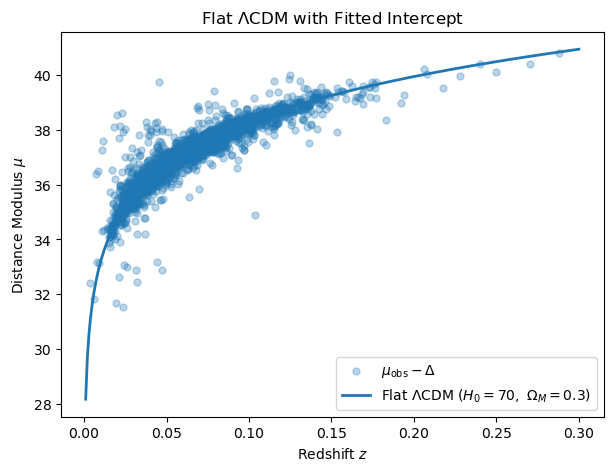

In [7]:
from astropy.cosmology import FlatLambdaCDM
import numpy as np
import matplotlib.pyplot as plt

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# model distance modulus at each SN's z
mu_model = cosmo.distmod(df["redshift"].values).value

# best-fit vertical shift (intercept) to align data with model
Delta = np.mean(df["mu_obs"].values - mu_model)            # or weighted mean if you have σ_μ
# Delta ≡ M0 - M0_true in “Tripp” language

# aligned data
mu_aligned = df["mu_obs"].values - Delta

# plot
z_grid = np.linspace(0.001, 0.3, 300)
mu_grid = cosmo.distmod(z_grid).value

plt.figure(figsize=(7,5))
plt.scatter(df["redshift"], mu_aligned, s=25, alpha=0.3, label=r"$\mu_{\mathrm{obs}}-\Delta$")
plt.plot(z_grid, mu_grid, lw=2, label=r"Flat $\Lambda$CDM ($H_0=70,\ \Omega_M=0.3$)")
plt.xlabel(r"Redshift $z$")
plt.ylabel(r"Distance Modulus $\mu$")
plt.title(r"Flat $\Lambda$CDM with Fitted Intercept")
plt.legend(); plt.show()